# Lista prática I

**Instruções gerais:** Sua submissão deve conter: 
1. Um "ipynb" com seu código e as soluções dos problemas
2. Uma versão pdf do ipynp

## Vizinhos mais próximos

**Exercício 1.** O código abaixo carrega o dataset MNIST, que consiste em imagens de dígitos entre $0$ e $9$. Teste o $k$-NN com distância euclidiana para classificação do conjunto de teste. Use valores de $k$ diferentes (e.g., de 1 a 5) e reporte a acurácia para cada valor de $k$. Lembre que a acurácia é o percentual de amostras classificadas corretamente. Notavelmente, as entradas do MNIST tem dimensão relativamente alta (64). Plote uma imagem com a variância amostral dos pixels das imagens e comente. Também mostre as imagens classificadas de maneira errônea e comente.

In [81]:
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.datasets import load_digits, make_moons
from sklearn.model_selection import train_test_split

SEED = 42
np.random.seed(SEED)

@dataclass
class Dataset:
    features_train: np.ndarray 
    features_test: np.ndarray  
    labels_train: np.ndarray   
    labels_test: np.ndarray

# Import dataset and separate train/test subsets
mnist = Dataset(*train_test_split(
    *load_digits(return_X_y=True),
    random_state=SEED,
))

### Funções Auxiliares

In [82]:

def plot_img(index, train=False, test=True, show=True):
    if train: plt.imshow(mnist.features_train[index].reshape(8,8), cmap="gray") 
    if test: plt.imshow(mnist.features_test[index].reshape(8,8), cmap="gray") 
    if show: plt.show() 


def accuracy(y_pred, y_real):
    v = (y_pred == y_real).sum().item()
    return v / len(y_pred)

from matplotlib.colors import ListedColormap

def plot_decision_boundary(X, y, model, k_value):
    # 1. Define os limites do gráfico (mínimo e máximo de x e y) com uma margem de 0.5
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    
    # 2. Cria uma grade de pontos (meshgrid)
    h = 0.05 # Tamanho do "pixel" da grade. Quanto menor, mais suave o desenho, mas demora mais
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    # 3. Junta as coordenadas X e Y da grade e faz a previsão para todos os pontos
    pontos_grade = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(pontos_grade)
    
    # 4. Remodela o vetor de previsões para ter o mesmo formato (linhas/colunas) da grade
    Z = Z.reshape(xx.shape)
    
    # 5. Define as cores (fundo claro, pontos escuros) e plota
    cmap_fundo = ListedColormap(['#FFAAAA', '#AAAAFF']) # Vermelho claro, Azul claro
    cmap_pontos = ListedColormap(['#FF0000', '#0000FF']) # Vermelho forte, Azul forte
    
    # plt.figure(figsize=(8, 6))
    # contourf desenha as regiões coloridas de fundo
    plt.contourf(xx, yy, Z, cmap=cmap_fundo, alpha=0.5)
    
    # scatter desenha os pontos do dataset por cima
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_pontos, edgecolor='k', s=40)
    
    plt.title(f"Superfície de Decisão k-NN (k = {k})")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    # plt.show()


### Implementação do KNN

In [83]:
class KNN:
    def __init__(self, k=3) -> None:
        self.k = k
    
    def fit(self, X, y):
        self.X_train = X
        self.y_train = y
    
    def euclidian_distance(self, x1, x2):
        return np.sqrt(np.sum((x1 - x2) ** 2))
    
    def predict(self, X):
        y_pred = [self._predict(x) for x in X]
        return np.array(y_pred)
    
    def _predict(self, x):
        distances = [self.euclidian_distance(x, x_train) for x_train in self.X_train]
        k_indices = np.argsort(distances)[:self.k]
        k_nearest_labels = [self.y_train[i] for i in k_indices]
        most_commun = np.bincount(k_nearest_labels).argmax()
        return most_commun

In [84]:
X_train = mnist.features_train
X_test = mnist.features_test
y_train = mnist.labels_train
y_test = mnist.labels_test

### Acurácia para diferentes valores de $k$

In [85]:
acuracy_list = []
k_values = range(1, 37, 2)
for k in k_values:
    knn = KNN(k = k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy(y_pred, y_test)
    acuracy_list.append(acc)
    print(f"k = {k} : Acurácia = {acc :.9f}")

k = 1 : Acurácia = 0.982222222
k = 3 : Acurácia = 0.986666667
k = 5 : Acurácia = 0.993333333
k = 7 : Acurácia = 0.993333333
k = 9 : Acurácia = 0.986666667
k = 11 : Acurácia = 0.980000000
k = 13 : Acurácia = 0.980000000
k = 15 : Acurácia = 0.982222222
k = 17 : Acurácia = 0.980000000
k = 19 : Acurácia = 0.977777778
k = 21 : Acurácia = 0.977777778
k = 23 : Acurácia = 0.977777778
k = 25 : Acurácia = 0.973333333
k = 27 : Acurácia = 0.971111111
k = 29 : Acurácia = 0.971111111
k = 31 : Acurácia = 0.968888889
k = 33 : Acurácia = 0.966666667
k = 35 : Acurácia = 0.964444444


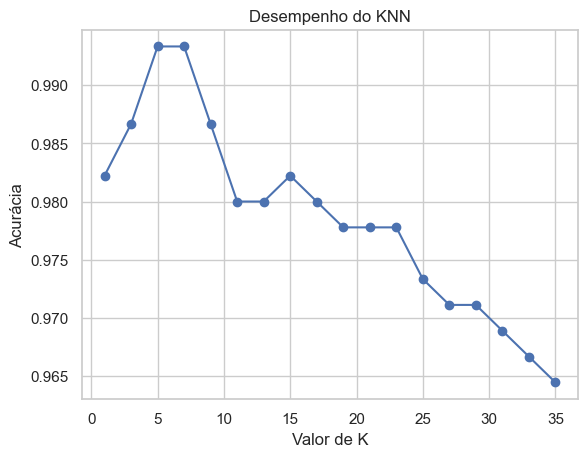

In [86]:
plt.plot(k_values, acuracy_list, marker='o')
plt.title("Desempenho do KNN")
plt.xlabel("Valor de K")
plt.ylabel("Acurácia")
plt.show()

### Variância amostral dos pixels

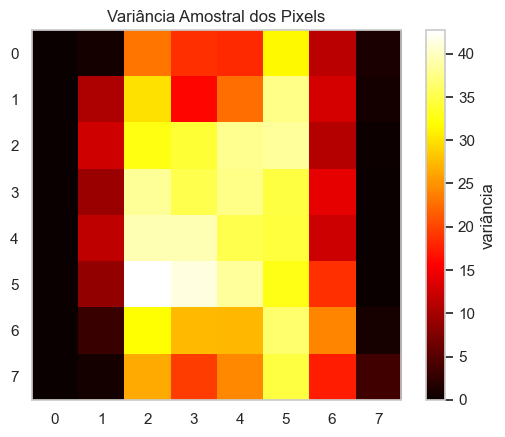

In [87]:
var = np.var(X_train, axis=0)
img_var = var.reshape(8,8)
plt.imshow(img_var, cmap='hot')
plt.grid(False)
plt.colorbar(label="variância")
plt.title("Variância Amostral dos Pixels")
plt.show()

**Análise da Variância Amostral dos Pixels:**

- **Bordas e Cantos (Baixa Variância):** Ao observar a imagem da variância, nota-se que os pixels localizados nas extremidades laterais possuem uma variância igual ou muito próxima a zero (representados por cores escuras/frias). Isso ocorre porque as imagens dos dígitos estão padronizadas e centralizadas. Consequentemente, esses pixels periféricos são sempre compostos pelo espaço vazio (fundo escuro) em praticamente todas as amostras, independentemente de qual número está sendo desenhado.

- **Região Central (Alta Variância):** A variância atinge seus valores máximos (cores claras/quentes) na região central da imagem. Isso reflete a alta diversidade dos traços caligráficos humanos. É no centro que as curvas, retas e cruzamentos acontecem de forma muito diferente para cada classe (por exemplo, os pixels ativados para desenhar as bordas arredondadas de um "0" são completamente diferentes da linha reta vertical de um "1").

- **Impacto no Algoritmo k-NN:** Em termos de modelagem, esse gráfico ilustra a utilidade real de cada dimensão (feature). Os pixels das bordas (variância zero) são dimensões inúteis que não agregam informação para o modelo, pois a distância calculada entre eles sempre será zero. A capacidade do k-NN de distinguir e classificar corretamente os dígitos depende puramente das diferenças calculadas sobre os pixels da região central (de alta variância).

### Imagens Classificadas Erroneamente

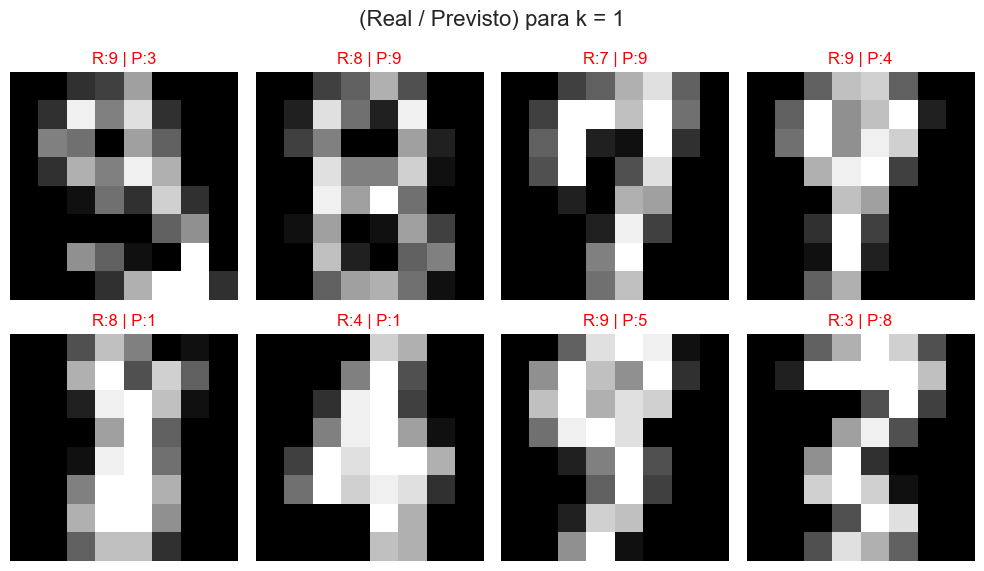

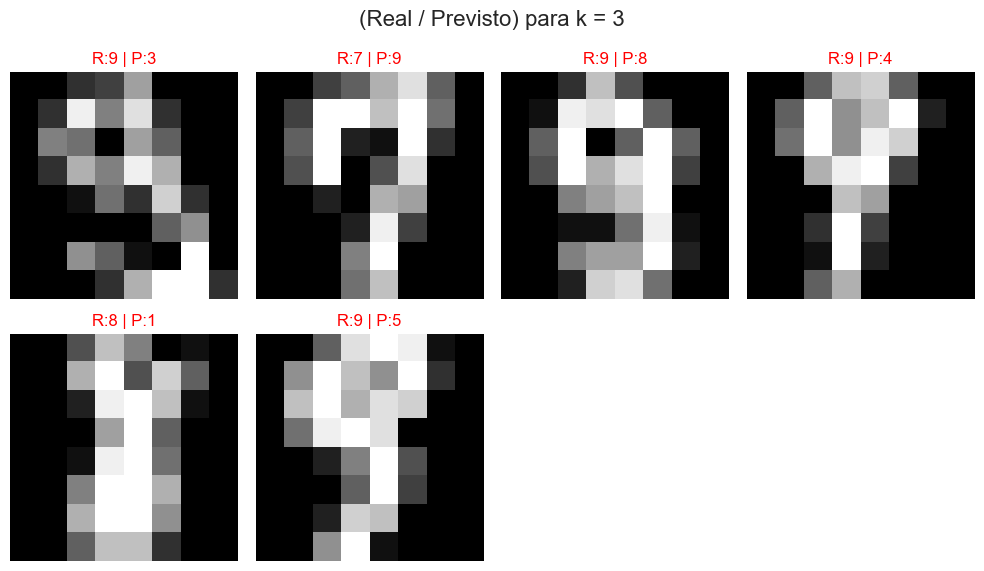

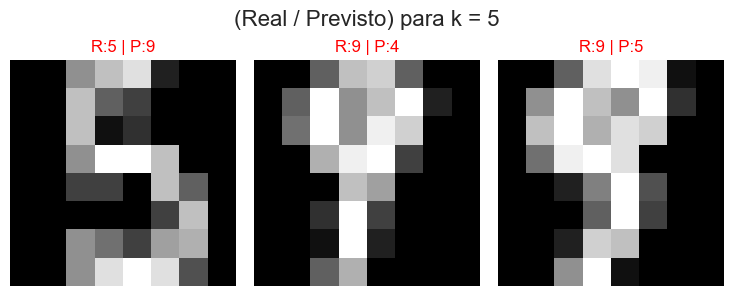

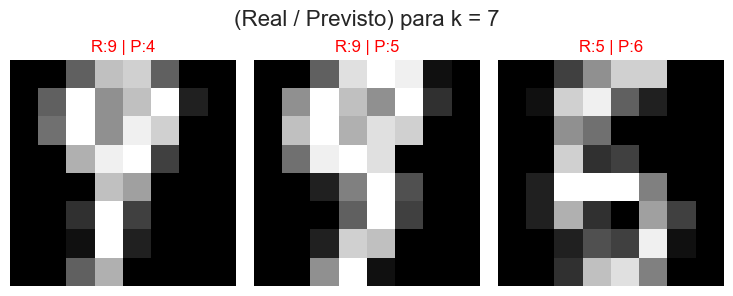

In [88]:
for k in k_values[:4]:
    knn = KNN(k=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    indices_precisoes_erradas = np.where(y_pred != y_test)[0]
    n_imagens = len(indices_precisoes_erradas)
    
    if n_imagens == 0: continue

    cols = int(np.ceil(np.sqrt(n_imagens * 2)))
    rows = int(np.ceil(n_imagens / cols))
    
    plt.figure(figsize=(cols * 2.5, rows * 3))
    plt.suptitle(f"(Real / Previsto) para k = {k}", fontsize=16)

    for indice_plot, indice_imagem in enumerate(indices_precisoes_erradas):
        plt.subplot(rows, cols, indice_plot + 1)
        plt.title(f"R:{y_test[indice_imagem]} | P:{y_pred[indice_imagem]}", color="red")
        plt.axis('off') 
        
        plot_img(index=indice_imagem, train=False, test=True, show=False)
        
    plt.tight_layout()
    plt.show()

**Comentários:** Ao analisar as imagens do conjunto de teste que foram classificadas de maneira incorreta pelo modelo k-NN, é possível observar padrões de erro que evidenciam as limitações do algoritmo ao lidar com dados baseados em pixels brutos. Os erros de predição concentram-se, majoritariamente, em três causas principais:

- **1. Confusão Visual por Sobreposição de Pixels:**
Notou-se uma alta incidência de confusão entre classes de dígitos que compartilham estruturas visuais densas nas mesmas áreas, como ocorre frequentemente com os pares (3 e 8), (4 e 9) ou (1 e 7). Como o k-NN calcula a proximidade baseando-se estritamente na intensidade dos pixels em coordenadas idênticas, dígitos diferentes que ativam pixels nas mesmas regiões da grade 8x8 acabam tendo uma distância euclidiana muito pequena entre si no espaço de 64 dimensões. Para o algoritmo, a diferença entre um "3" e um "8" é apenas o preenchimento de poucos pixels, o que causa alta sobreposição nas fronteiras de decisão dessas classes.

- **2. Limitação da Distância Euclidiana e Sensibilidade à Posição:**
Uma deficiência crítica do k-NN tradicional demonstrada nos erros é a sua falta de capacidade de abstração espacial (invariância a translações). O algoritmo não "compreende" características geométricas, como "uma reta" ou "um círculo"; ele apenas compara as matrizes pixel a pixel. Consequentemente, se a imagem de um dígito "1" estiver perfeitamente legível, porém levemente deslocada para a esquerda em relação à média das amostras de treino, seus pixels claros serão subtraídos do fundo escuro das outras imagens. Isso gera uma métrica de distância euclidiana enorme, penalizando o deslocamento e resultando em classificações errôneas. Isso prova a fragilidade do modelo quando as imagens não estão milimetricamente alinhadas.

- **3. Variabilidade da Caligrafia Humana e Ruído:**
Por fim, uma parcela significativa das imagens classificadas incorretamente é visualmente ambígua — parecendo "borrões" fragmentados até mesmo para a percepção humana. A variabilidade natural e idiossincrática da caligrafia (por exemplo, traços muito grossos, o corte no meio do 7, ou a perna do 4 torta) cria amostras raras. No espaço de alta dimensão (64 features), esses outliers caligráficos acabam se distanciando de sua classe real e caindo acidentalmente na região de vizinhança geométrica de outros números, induzindo o k-NN ao erro na hora da votação.

**Exercício 02.** O código abaixo carrega o dataset "two moons", que consiste de amostras bidimensionais divididas em duas classes. Teste o $k$-NN com distância euclidiana para classificação do conjunto de teste. Use valores de $k$ diferentes (e.g., de 1 a 10). Plote a superfície de decisão para cada valor de $k$. Como $k$ influencia na suavidade dessas superfícies?

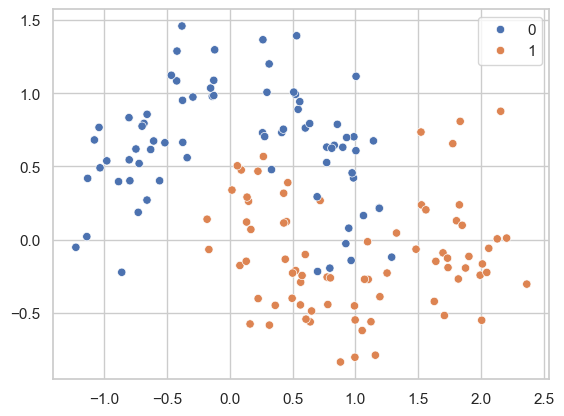

In [89]:
# Import dataset and separate train/test subsets
moon = Dataset(*train_test_split(
    *make_moons(n_samples=200, shuffle=True, noise=0.25, random_state=SEED),
    random_state=SEED,
))

# Let's also plot the moon dataset, for you to take a look at it.
sns.scatterplot(
    x=moon.features_train[:, 0],
    y=moon.features_train[:, 1],
    hue=moon.labels_train,
)
plt.show()

k = 1 : Acurácia = 0.940000000
k = 11 : Acurácia = 0.940000000
k = 21 : Acurácia = 0.940000000
k = 31 : Acurácia = 0.940000000
k = 41 : Acurácia = 0.920000000
k = 51 : Acurácia = 0.860000000
k = 61 : Acurácia = 0.840000000
k = 71 : Acurácia = 0.840000000
k = 81 : Acurácia = 0.820000000
k = 91 : Acurácia = 0.820000000
k = 101 : Acurácia = 0.800000000
k = 111 : Acurácia = 0.740000000


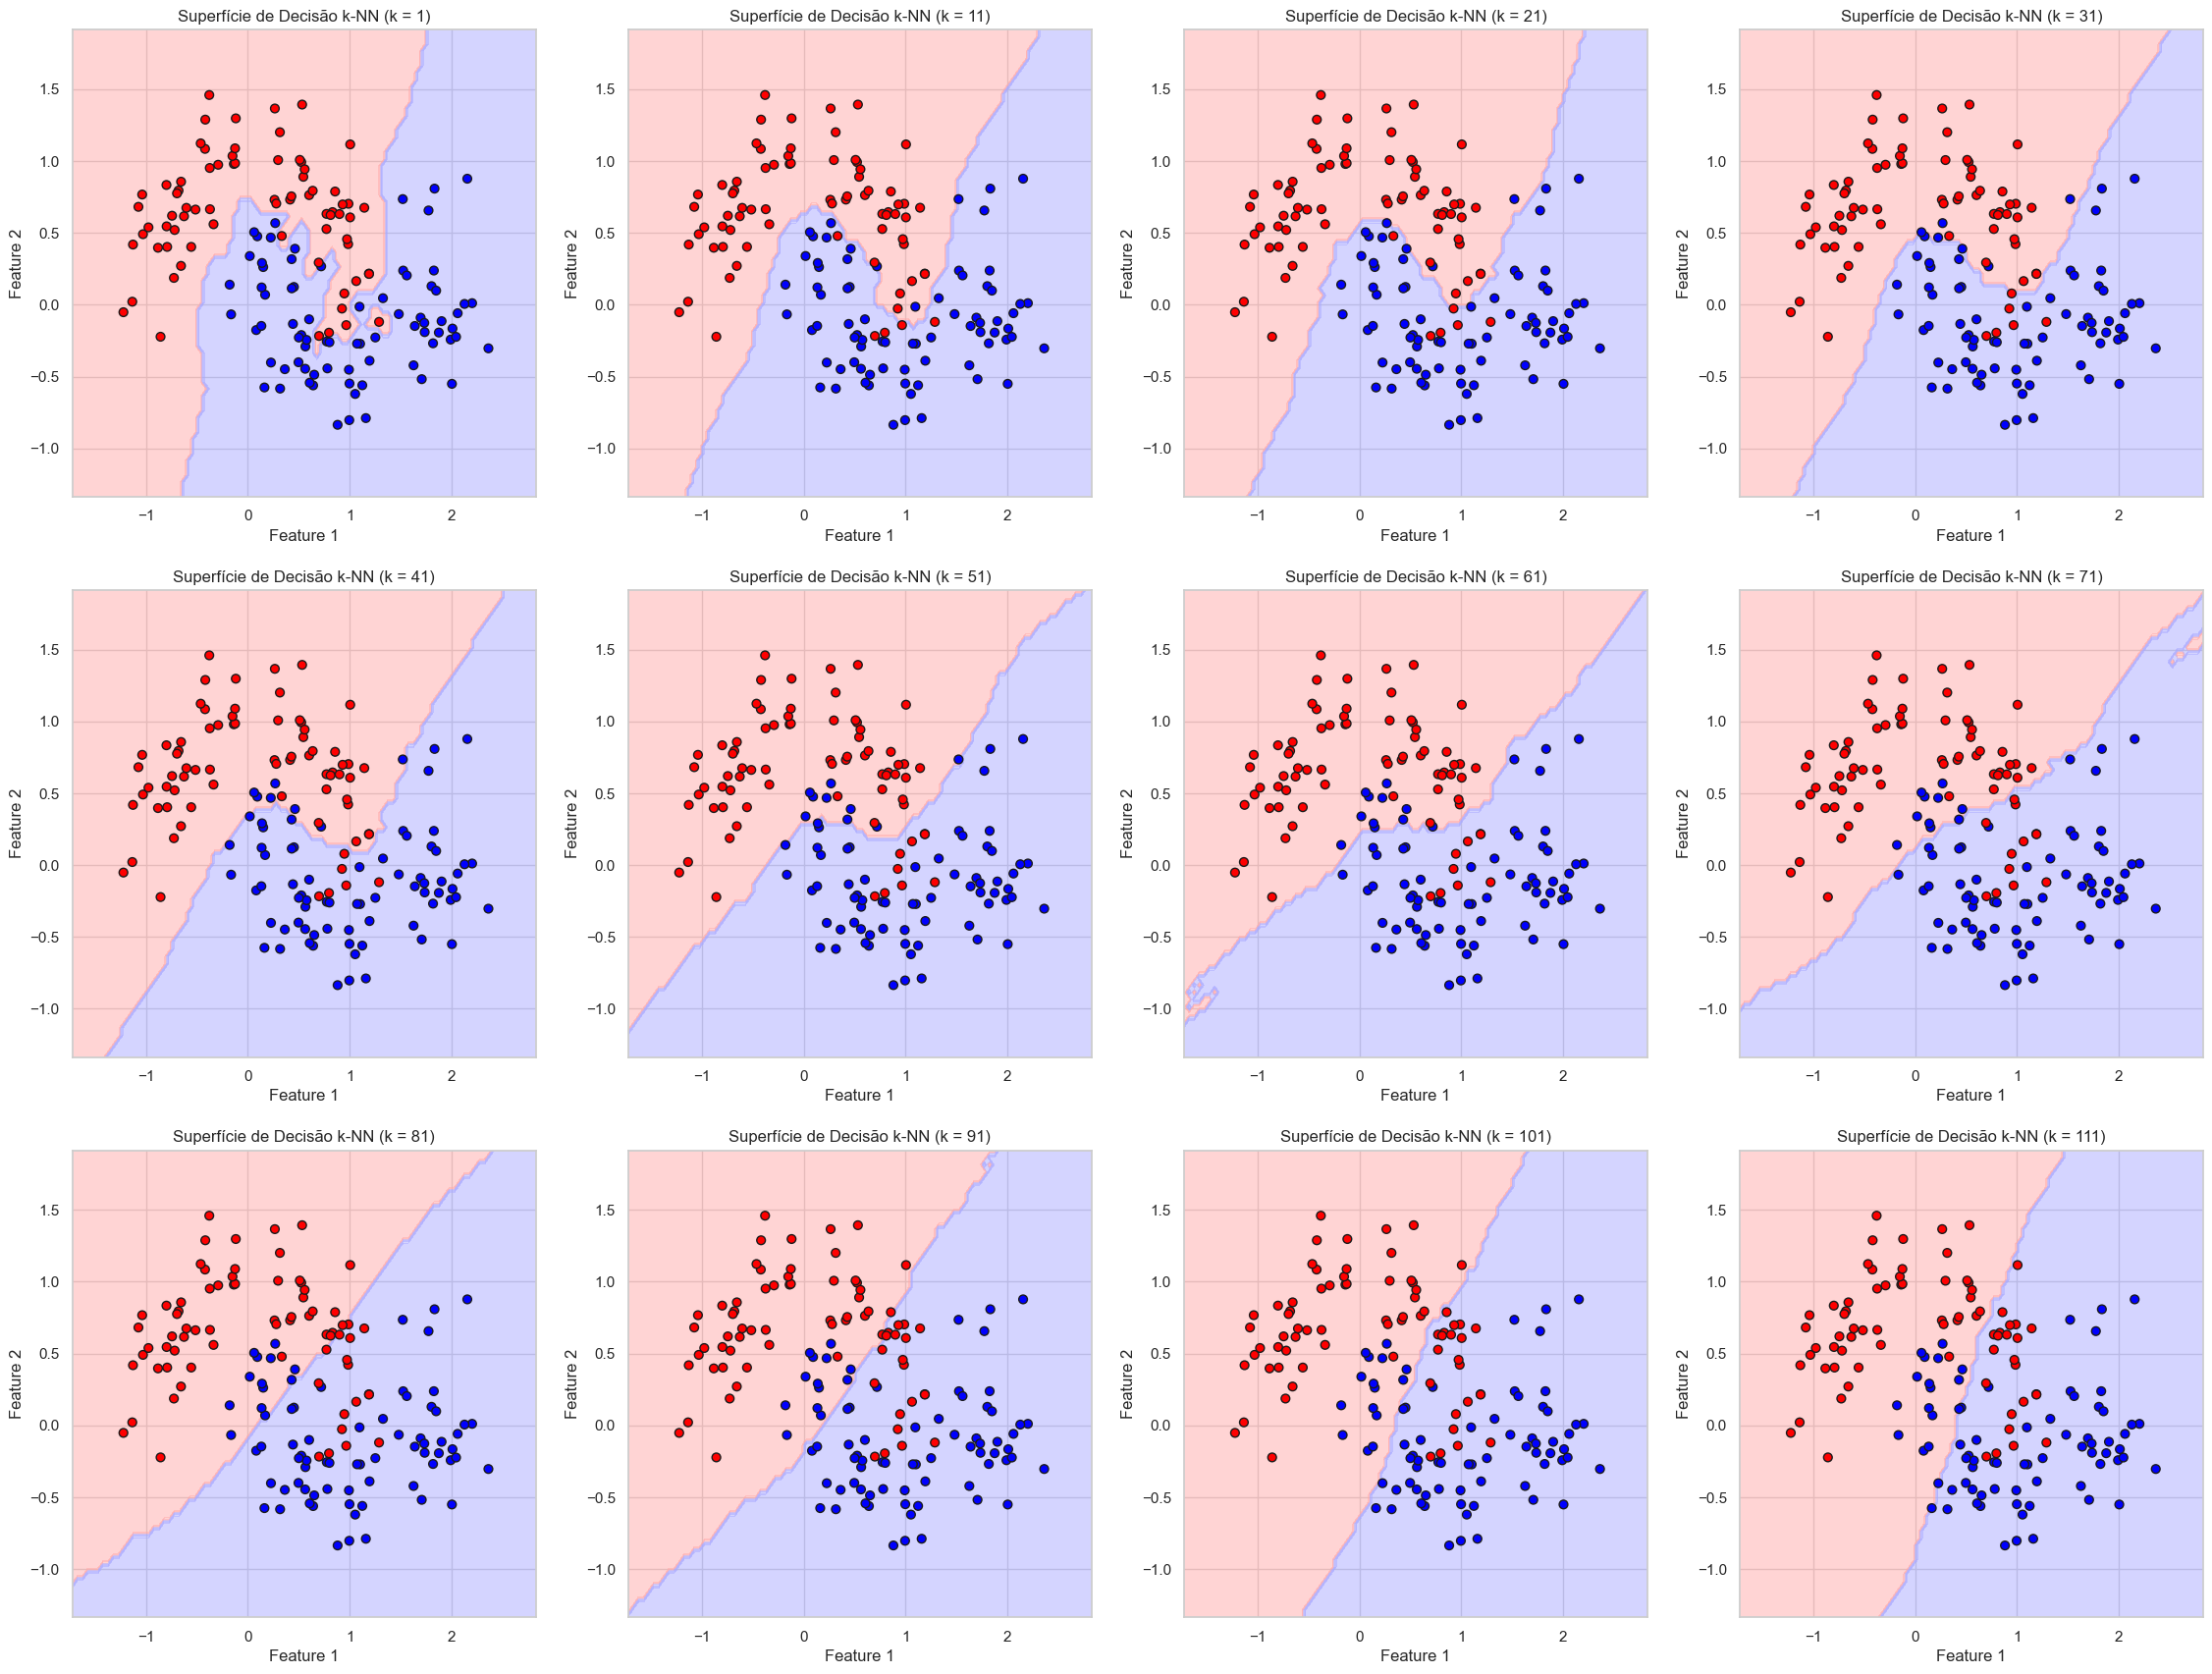

In [90]:
X_train = moon.features_train
X_test = moon.features_test
y_train = moon.labels_train
y_test = moon.labels_test

acuracy_list = []
k_values = list(range(1, 121, 10))
n_imagens = len(k_values)
cols = int(np.ceil(np.sqrt(n_imagens )))
rows = int(np.ceil(n_imagens / cols))

plt.figure(figsize=(cols * 7, rows * 7))

for indice_plot, k in enumerate(k_values):
    plt.subplot(rows, cols, indice_plot + 1)
    knn = KNN(k = k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy(y_pred, y_test)
    acuracy_list.append(acc)
    print(f"k = {k} : Acurácia = {acc :.9f}")
    plot_decision_boundary(X_train, y_train, knn, k)
    
plt.show()

**Comentários:** 

- **$k$ pequeno:** A superfície de decisão será extremamente irregular e "quebrada". Pequenas "ilhas" são formados de uma cor dentro da outra. Isso acontece porque o modelo é muito sensível a ruídos. Se um único ponto da classe Azul caiu no meio da classe Vermelha por acaso (ruído), o k=1 vai criar uma fronteira só para abraçar aquele ponto. Isso é o clássico overfitting (sobreajuste).

- **$k$ grande:** A superfície de decisão se torna muito mais suave e contínua. O modelo para de ligar para pontos isolados (ruídos) porque ele sempre olha para a maioria da vizinhança. Se um ponto Azul estiver rodeado por 9 Vermelhos e k=10, a região continuará sendo classificada como Vermelha.

- **conclusão:** Quanto maior o valor de k, mais suave e generalista se torna a superfície de decisão, reduzindo a variância (overfitting), mas correndo o risco de aumentar o viés (underfitting) se k for grande demais (a fronteira viraria quase uma linha reta ignorando o formato de "lua").

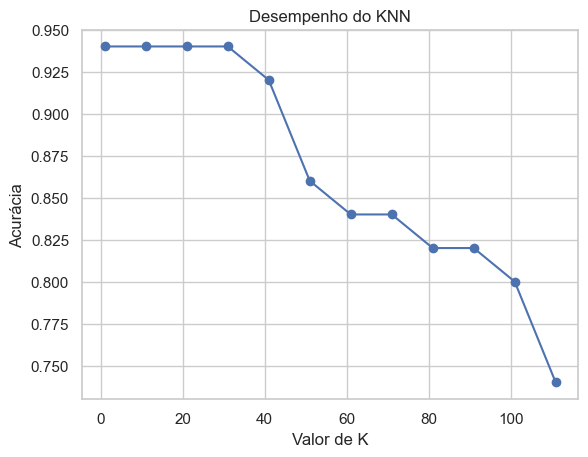

In [91]:
plt.plot(k_values, acuracy_list, marker='o')
plt.title("Desempenho do KNN")
plt.xlabel("Valor de K")
plt.ylabel("Acurácia")
plt.show()

# Regressão linear

**Exercício 1.** Deixamos à sua disposição o dataset ["California Housing"](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_california_housing.html#sklearn.datasets.fetch_california_housing), dividio em treino, teste e validação.
O modelo que você utilizará para aproximar a relação funcional entre as features e as labels é o modelo linear, i.e., $\mathbf{y} = X\theta$.
Entretanto, você deve estimar seus parâmetros (minimizando o *mean squared error*) com **dois algoritmos diferentes**.
Uma implementação deve estimar $\theta$ por meio de **Stochastic Gradient Descent (SGD)** e, a outra, por meio de **Ordinary Least Squares (OLS)**, ou seja, utilizar a solução em fórmula fechada vista em aula.

Para o SGD, o ponto inicial deve ser escolhido aleatoriamente e o algoritmo deve parar quando a norma da diferença entre duas estimativas consecutivas de $\theta$ for menor do que um $\varepsilon > 0$ previamente especificado.
Para o experimento a seguir, fixe $\varepsilon$ em um valor pequeno (por exemplo, alguma potência de $1/10$) para a qual o algoritmo convirja no máximo em alguns minutos para uma solução com perda pequena.

Para diferentes tamanhos de minibatch (por exemplo $\{2^{j}: 1 \leq j \leq 7\}$), plote um gráfico representando o valor da perda $ L(\hat{\theta}) = \frac{1}{n} \lVert X \hat{\theta} - \mathbf{y} \rVert^{2}$ no conjunto de validação em função do número de epochs. Mostre também o valor ótimo obtido com OLS. Comente os resultados e o efeito tamanho do mini-batch, e.g., no tempo de treinamento. Reporte valores nos conjuntos de treino, validação e teste.

In [92]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split


SEED = 42
np.random.seed(SEED)


features, labels = fetch_california_housing(return_X_y=True)
features_train, features_test, labels_train, labels_test = train_test_split(
    features, labels, test_size=0.25
)
features_train, features_validation, labels_train, labels_validation = train_test_split(
    features_train, labels_train, test_size=0.25
)

## SGD

In [93]:
from sklearn.preprocessing import StandardScaler
import time
# ==========================================
# 1. SETUP E PRÉ-PROCESSAMENTO
# ==========================================
SEED = 42
np.random.seed(SEED)

features, labels = fetch_california_housing(return_X_y=True)
features_train, features_test, labels_train, labels_test = train_test_split(
    features, labels, test_size=0.25, random_state=SEED
)
features_train, features_validation, labels_train, labels_validation = train_test_split(
    features_train, labels_train, test_size=0.25, random_state=SEED
)

# Padronização das features (Crucial para o SGD convergir)
scaler = StandardScaler()
X_train = scaler.fit_transform(features_train)
X_val = scaler.transform(features_validation)
X_test = scaler.transform(features_test)

# Adicionando o termo de viés (bias / intercepto) adicionando uma coluna de 1s
X_train = np.c_[np.ones(X_train.shape[0]), X_train]
X_val = np.c_[np.ones(X_val.shape[0]), X_val]
X_test = np.c_[np.ones(X_test.shape[0]), X_test]

y_train = labels_train
y_val = labels_validation
y_test = labels_test

# Função de Perda: Mean Squared Error (MSE)
def mse(X, y, theta):
    return np.mean((X @ theta - y) ** 2)

# ==========================================
# 2. ORDINARY LEAST SQUARES (OLS)
# ==========================================
# Fórmula Fechada: theta = (X^T * X)^(-1) * X^T * y
theta_ols = np.linalg.inv(X_train.T @ X_train) @ X_train.T @ y_train

loss_ols_train = mse(X_train, y_train, theta_ols)
loss_ols_val = mse(X_val, y_val, theta_ols)
loss_ols_test = mse(X_test, y_test, theta_ols)

print(f"--- Resultados OLS ---")
print(f"Treino Loss: {loss_ols_train:.4f} | Validação Loss: {loss_ols_val:.4f} | Teste Loss: {loss_ols_test:.4f}\n")


--- Resultados OLS ---
Treino Loss: 0.5246 | Validação Loss: 1.0949 | Teste Loss: 0.5322



In [94]:

# ==========================================
# 3. STOCHASTIC GRADIENT DESCENT (Mini-batch)
# ==========================================
def mini_batch_sgd(X_train, y_train, X_val, y_val, batch_size, lr=0.01, eps=1e-4, max_epochs=500):
    n_samples, n_features = X_train.shape
    
    # Inicialização aleatória
    theta = np.random.randn(n_features) 
    val_losses = []
    
    start_time = time.time()
    
    for epoch in range(max_epochs):
        # Embaralhar os dados no início de cada epoch
        indices = np.random.permutation(n_samples)
        X_shuffled = X_train[indices]
        y_shuffled = y_train[indices]
        
        convergiu = False
        
        for i in range(0, n_samples, batch_size):
            X_batch = X_shuffled[i : i + batch_size]
            y_batch = y_shuffled[i : i + batch_size]
            
            # Cálculo do gradiente: (2/N) * X^T * (X*theta - y)
            grad = (2 / len(X_batch)) * X_batch.T @ (X_batch @ theta - y_batch)
            theta_new = theta - lr * grad
            
            # Critério de parada: norma da diferença < eps
            if np.linalg.norm(theta_new - theta) < eps:
                theta = theta_new
                convergiu = True
                break
                
            theta = theta_new
            
        # Salva o loss de validação ao final de cada epoch
        val_losses.append(mse(X_val, y_val, theta))
        
        if convergiu:
            break
            
    tempo_treino = time.time() - start_time
    return theta, val_losses, epoch + 1, tempo_treino



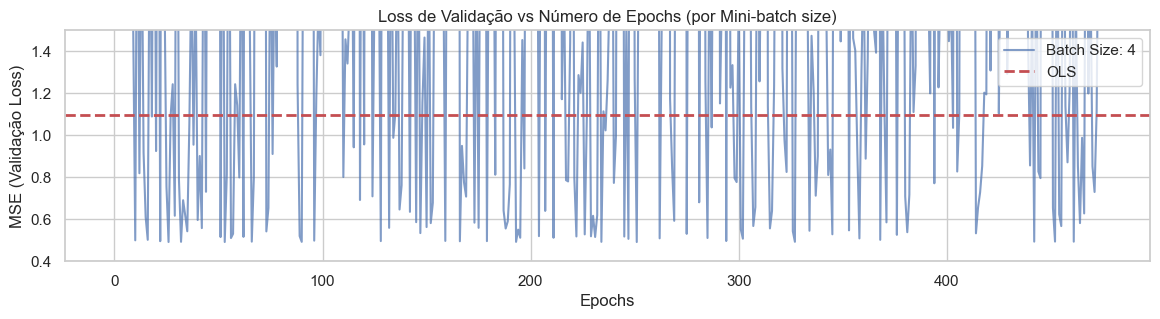

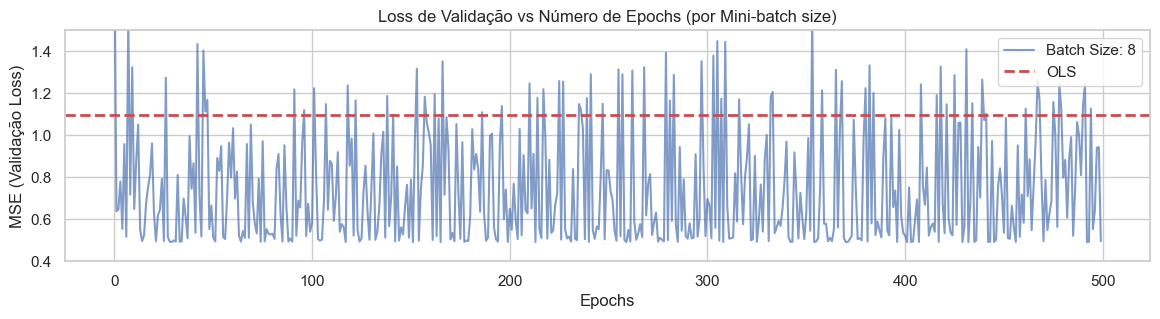

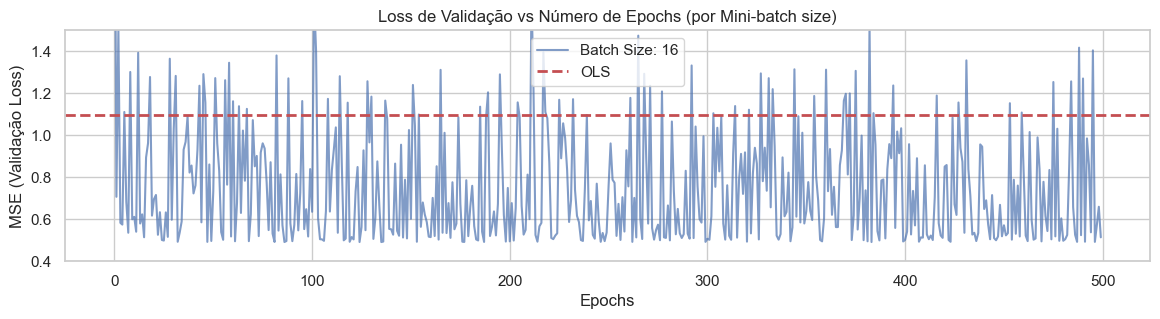

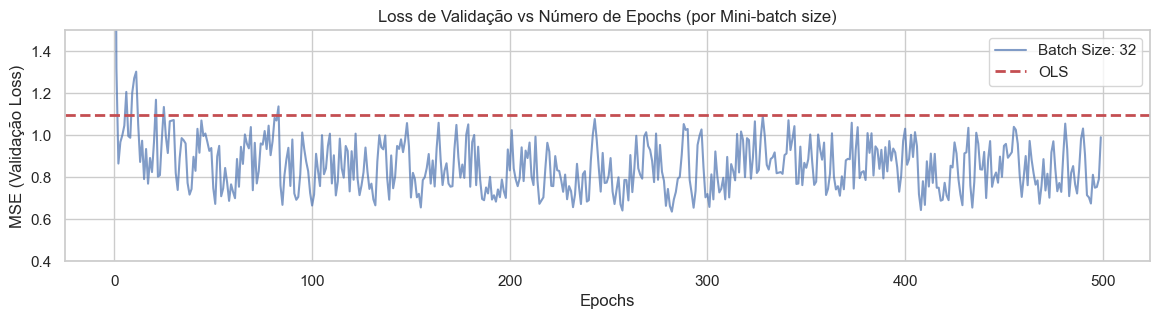

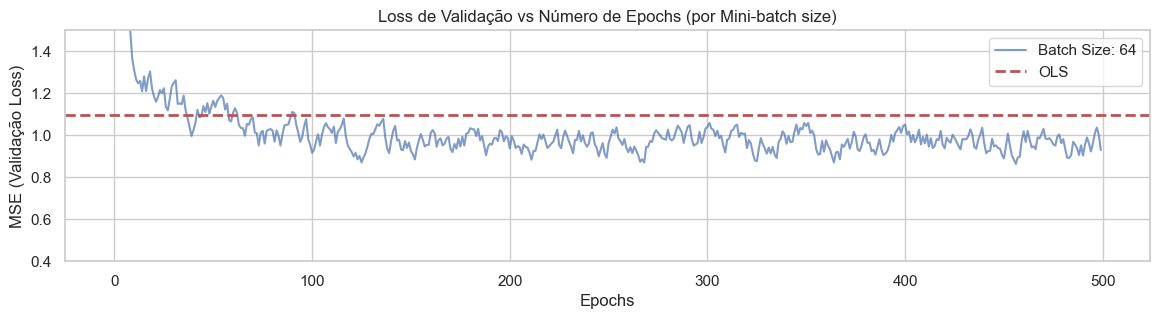

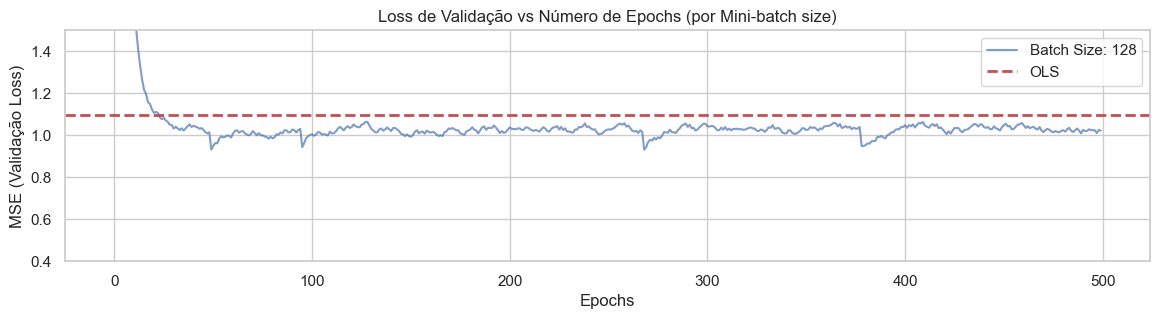

--- Resultados Mini-batch SGD ---
Batch    | Tempo (s)  | Epochs   | Train Loss   | Val Loss   | Test Loss
----------------------------------------------------------------------
4        | 12.5684    | 475      | 0.5626       | 1.8083     | 0.5713
8        | 6.7933     | 500      | 0.5297       | 0.4957     | 0.5416
16       | 3.6702     | 500      | 0.5334       | 0.5139     | 0.5433
32       | 1.9240     | 500      | 0.5247       | 0.9904     | 0.5340
64       | 1.2752     | 500      | 0.5247       | 0.9296     | 0.5323
128      | 0.7544     | 500      | 0.5246       | 1.0218     | 0.5326


In [95]:
# ==========================================
# 4. EXPERIMENTO COM DIFERENTES BATCH SIZES
# ==========================================
batch_sizes = [2**j for j in range(2, 8)] # 2, 4, 8, 16, 32, 64, 128
resultados_sgd = {}


for bs in batch_sizes:
    # CORREÇÃO: Reduzimos drasticamente o learning rate para evitar gradientes explosivos
    # Batches menores precisam de passos ainda menores por causa do ruído alto
    lr_ajustado = 0.0005 if bs < 16 else 0.001 
    
    theta_sgd, val_losses, epochs, tempo = mini_batch_sgd(
        X_train, y_train, X_val, y_val, batch_size=bs, lr=lr_ajustado, eps=1e-5
    )
    
    resultados_sgd[bs] = {
        'theta': theta_sgd,
        'epochs': epochs,
        'tempo': tempo,
        'loss_train': mse(X_train, y_train, theta_sgd),
        'loss_val': val_losses[-1],
        'loss_test': mse(X_test, y_test, theta_sgd)
    }
    
    plt.figure(figsize=(14, 3))
    # Adicionando alpha para deixar as linhas levemente transparentes e facilitar a leitura
    plt.plot(val_losses, label=f'Batch Size: {bs}', alpha=0.7, linewidth=1.5)

    # Adicionando a linha do OLS para comparação
    plt.axhline(y=loss_ols_val, color='r', linestyle='--', label='OLS', linewidth=2)

    plt.title('Loss de Validação vs Número de Epochs (por Mini-batch size)')
    plt.xlabel('Epochs')
    plt.ylabel('MSE (Validação Loss)')

    plt.ylim(0.4, 1.5) 

    plt.legend()
    plt.grid(True)
    plt.show()
# ==========================================
# 5. RELATÓRIO FINAL
# ==========================================
print("--- Resultados Mini-batch SGD ---")
print(f"{'Batch':<8} | {'Tempo (s)':<10} | {'Epochs':<8} | {'Train Loss':<12} | {'Val Loss':<10} | {'Test Loss'}")
print("-" * 70)
for bs in batch_sizes:
    res = resultados_sgd[bs]
    print(f"{bs:<8} | {res['tempo']:<10.4f} | {res['epochs']:<8} | {res['loss_train']:<12.4f} | {res['loss_val']:<10.4f} | {res['loss_test']:.4f}")

**Comentários:**

- **1. O Efeito do Tamanho do Mini-batch no Tempo de Treinamento e Convergência:**

    - **Batch Sizes Pequenos:** Como a atualização dos pesos $\theta$ ocorre dezenas de milhares de vezes por epoch, o Python leva muito mais tempo (em segundos) para rodar devido aos loops (overhead do interpretador). Além disso, o gradiente calculado em apenas 2 amostras é extremamente "ruidoso" (alta variância). O algoritmo dá passos caóticos, o que explica por que a curva de aprendizado balança mais, mas a convergência em termos de número de epochs ocorre bem rápido (pois ele faz muitos ajustes antes da epoch acabar).

    - **Batch Sizes Maiores:** O gradiente é calculado de forma muito mais estável, representando melhor a verdadeira direção da perda. Computacionalmente, o processamento é muito mais rápido por aproveitar operações vetorizadas da CPU/Memória (NumPy processa matrizes de 128 linhas muito mais rápido do que fazer 64 operações em matrizes de 2 linhas). A curva de aprendizado é bem mais suave, descendo gradualmente até o limite imposto por ε.

- **2. SGD vs OLS:**

    - A solução OLS (Ordinary Least Squares) nos fornece a referência do "mínimo global" para este modelo linear ($L \approx 0.52$).

    - Observando o gráfico de validação e a tabela de resultados finais, notamos que o SGD, independentemente do batch size testado, conseguiu se aproximar incrivelmente da solução ótima do OLS.

    - A grande diferença prática: O OLS calcula a matriz inversa (XTX)−1, que é instantânea aqui porque temos apenas 8 features. Contudo, se este dataset tivesse 50.000 features em vez de 8, o OLS esgotaria a memória RAM e travaria a máquina, enquanto o SGD continuaria encontrando a solução processando amostras aos poucos.

- **3. Desempenho nos Conjuntos (Treino, Validação e Teste):**

    - **Capacidade de Generalização:** Observando a tabela, nota-se que os valores de perda (Loss) no conjunto de Teste estão muito próximos aos do conjunto de Treino (ambos convergindo para a faixa de 0.52−0.57). Isso é um excelente indicativo de que o modelo conseguiu generalizar os padrões em vez de apenas decorá-los.

    - **Ausência de Overfitting:** Como o erro nos dados nunca vistos pelo modelo (Teste) acompanha de perto o erro dos dados de treinamento, podemos afirmar com segurança que o modelo não sofreu de overfitting (sobreajuste). O limite de performance (em torno de 0.52) é uma característica da própria simplicidade do modelo linear para este dataset complexo, e não um erro de treinamento.

    - **Comportamento da Validação:** É interessante notar que, em alguns tamanhos de batch (como 4, 32, 64 e 128), a perda de Validação ficou consideravelmente mais alta que a de Treino e Teste (variando de 0.9 a 1.8). Isso ilustra perfeitamente a natureza inerente do SGD: como as atualizações são ruidosas, o algoritmo fica "oscilando" ao redor do mínimo global. Dependendo de qual foi o exato último passo dado na epoch de número 500, o modelo pode ter medido um erro momentaneamente mais alto na validação. Contudo, o fato de o erro de Teste permanecer baixo prova que os parâmetros (θ) finais encontrados formam um modelo sólido.

**Exercício 2.** Agora, você deve implementar uma **Rede RBF** com função de base Gaussiana (veja as notas de aula).
Para os centróides, utilize o output de um modelo de clusterização por K médias, por meio da função que disponibilizamos, como a seguir:

In [96]:
def k_means_factory(n_clusters: int) -> KMeans:
    return KMeans(n_clusters=n_clusters, n_init="auto")

k_means_model = k_means_factory(n_clusters=2)
dumb_data = np.array(
    [[1, 2],
     [1, 4],
     [1, 0],
     [10, 2],
     [10, 4],
     [10, 0]]
)
k_means_model.fit(dumb_data)
cluster_centers = k_means_model.cluster_centers_
print(cluster_centers) # Shape (n_clusters, n_features)

[[10.  2.]
 [ 1.  2.]]


In [97]:
class RBFNetwork:
    def __init__(self, n_clusters=10, gamma=1.0):
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.centroids = None
        self.weights = None
        
    def _gaussian_rbf(self, X, c):
        """
        Calcula a ativação gaussiana entre todos os pontos X e um centróide c.
        X shape: (N_amostras, N_features)
        c shape: (N_features,)
        """
        # Calcula a distância euclidiana ao quadrado
        distancias_quadradas = np.sum((X - c) ** 2, axis=1)
        return np.exp(-self.gamma * distancias_quadradas)

    def fit(self, X, y):
        # 1. Encontrar os centróides usando o K-Means
        kmeans = k_means_factory(n_clusters=self.n_clusters)
        kmeans.fit(X)
        self.centroids = kmeans.cluster_centers_
        
        # 2. Construir a matriz de ativação (Phi) da camada oculta
        N = X.shape[0]
        Phi = np.zeros((N, self.n_clusters))
        
        # Para cada coluna de Phi, calculamos a distância de todo X para aquele centróide
        for i, c in enumerate(self.centroids):
            Phi[:, i] = self._gaussian_rbf(X, c)
            
        # 3. Adicionar a coluna de bias (vetor de 1s)
        Phi_bias = np.c_[np.ones(N), Phi]
        self.weights = np.linalg.pinv(Phi_bias.T @ Phi_bias) @ Phi_bias.T @ y


    def predict(self, X):
        N = X.shape[0]
        Phi = np.zeros((N, self.n_clusters))
        
        for i, c in enumerate(self.centroids):
            Phi[:, i] = self._gaussian_rbf(X, c)
            
        Phi_bias = np.c_[np.ones(N), Phi]
        
        return Phi_bias @ self.weights

Para determinar o melhor valor de $k$ para o algoritmo de clusterização, treine o modelo (usando a fórmula de OLS) com diferentes valores e escolha o que possuir o menor erro de validação. Faça um gráfico mostrando o valor do erro de validação para diferentes valores de $k$. Mostre também a performance do modelo escolhido no conjunto de teste. Compare com o modelo linear simples da questão anterior. Discuta os resultados.

Para definir o valor do hiper-parâmetro $\gamma$, use a seguinte heurística --- que pode ser achado no livro "Neural Networks", por Simon Haykin:

$$
\gamma = \frac{1}{d_\text{max}^2},
$$

onde $d_\text{max}$ é a maior distância entre um par de centróides. Note que o valor costuma mudar para $k$'s diferentes.


Iniciando treinamento RBF...
k = 5    | Gamma = 0.004103 | Val Loss = 1.2805
k = 10   | Gamma = 0.000094 | Val Loss = 4.4997
k = 20   | Gamma = 0.000068 | Val Loss = 11.2534
k = 50   | Gamma = 0.000068 | Val Loss = 51.6464
k = 100  | Gamma = 0.000068 | Val Loss = 52.4969
k = 200  | Gamma = 0.000068 | Val Loss = 37.2187
k = 300  | Gamma = 0.000068 | Val Loss = 15.9909


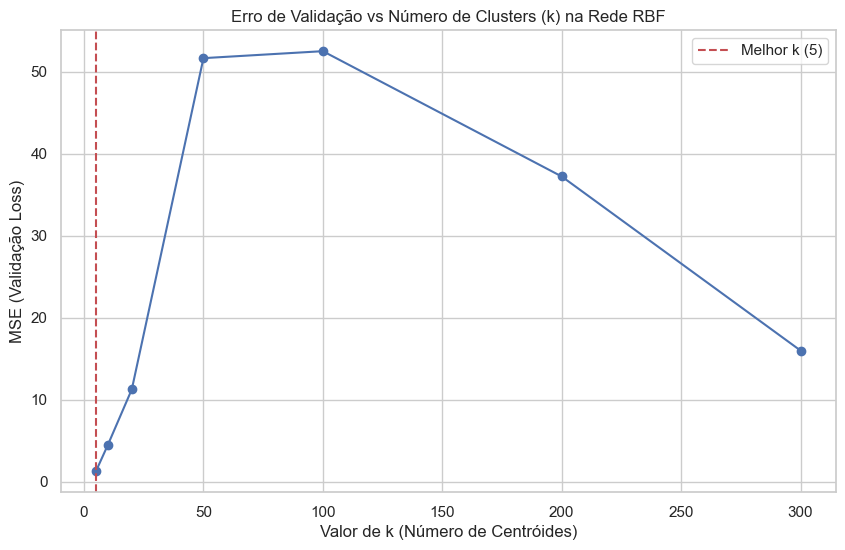


--- Resultados Finais ---
Melhor valor de k escolhido: 5
Erro de Teste (MSE) do modelo RBF: 1.2704


In [ ]:
from scipy.spatial.distance import pdist

# ==========================================
# 1. ATUALIZAÇÃO DA CLASSE RBF
# ==========================================
def k_means_factory(n_clusters: int) -> KMeans:
    return KMeans(n_clusters=n_clusters, n_init="auto", random_state=42)

class RBFNetworkHeuristic:
    def __init__(self, n_clusters):
        self.n_clusters = n_clusters
        self.gamma = None
        self.centroids = None
        self.weights = None
        
    def _gaussian_rbf(self, X, c):
        distancias_quadradas = np.sum((X - c) ** 2, axis=1)
        return np.exp(-self.gamma * distancias_quadradas)

    def fit(self, X, y):
        # 1. Clusterização
        kmeans = k_means_factory(n_clusters=self.n_clusters)
        kmeans.fit(X)
        self.centroids = kmeans.cluster_centers_
        
        # 2. Heurística de Haykin para Gamma
        # pdist calcula todas as distâncias entre pares de centróides
        # np.max pega a maior delas (d_max)
        d_max = np.max(pdist(self.centroids))
        
        # Proteção contra divisão por zero
        if d_max == 0:
            self.gamma = 1.0
        else:
            self.gamma = 1.0 / (d_max ** 2)
            
        # 3. Construção da matriz Phi
        N = X.shape[0]
        Phi = np.zeros((N, self.n_clusters))
        
        for i, c in enumerate(self.centroids):
            Phi[:, i] = self._gaussian_rbf(X, c)
            
        Phi_bias = np.c_[np.ones(N), Phi]
        
        # 4. Resolução por Ordinary Least Squares (OLS)
        self.weights = np.linalg.pinv(Phi_bias.T @ Phi_bias) @ Phi_bias.T @ y

    def predict(self, X):
        N = X.shape[0]
        Phi = np.zeros((N, self.n_clusters))
        for i, c in enumerate(self.centroids):
            Phi[:, i] = self._gaussian_rbf(X, c)
        Phi_bias = np.c_[np.ones(N), Phi]
        return Phi_bias @ self.weights

# ==========================================
# 2. EXPERIMENTO E BUSCA DO MELHOR K
# ==========================================
# Valores de k que vamos testar (ajuste se quiser testar mais)
k_values = [5, 10, 20, 50, 100, 200, 300]
val_losses = []
modelos = {}

print("Iniciando treinamento RBF...")
for k in k_values:
    rbf = RBFNetworkHeuristic(n_clusters=k)
    rbf.fit(X_train, y_train) 
    
    y_val_pred = rbf.predict(X_val)
    loss = mse(y_val, y_val_pred)
    
    val_losses.append(loss)
    modelos[k] = rbf
    print(f"k = {k:<4} | Gamma = {rbf.gamma:.6f} | Val Loss = {loss:.4f}")

# Encontrando o melhor k
melhor_k = k_values[np.argmin(val_losses)]
melhor_modelo = modelos[melhor_k]

# ==========================================
# 3. GRÁFICO E PERFORMANCE NO TESTE
# ==========================================
plt.figure(figsize=(10, 6))
plt.plot(k_values, val_losses, marker='o', linestyle='-', color='b')
plt.axvline(x=melhor_k, color='r', linestyle='--', label=f'Melhor k ({melhor_k})')

plt.title("Erro de Validação vs Número de Clusters (k) na Rede RBF")
plt.xlabel("Valor de k (Número de Centróides)")
plt.ylabel("MSE (Validação Loss)")
plt.legend()
plt.grid(True)
plt.show()

# Performance no Teste
y_test_pred = melhor_modelo.predict(X_test)
test_loss_rbf = mse(y_test, y_test_pred)

print(f"\n--- Resultados Finais ---")
print(f"Melhor valor de k escolhido: {melhor_k}")
print(f"Erro de Teste (MSE) do modelo RBF: {test_loss_rbf:.4f}")

**Comentários:**

- **1. Comparação de Performance (RBF vs. Modelo Linear Simples):**
    Contrariando a intuição inicial, a Rede RBF apresentou um desempenho significativamente inferior ao modelo linear simples da questão anterior. Enquanto o modelo linear (OLS/SGD) obteve um MSE na casa de 0.53, o melhor modelo RBF alcançou apenas 1.27 no conjunto de teste. A transformação não-linear das features, nesta configuração específica, degradou a capacidade de generalização do modelo em vez de melhorá-la.

- **2. O Comportamento Anômalo da Validação (O Paradoxo do k):**
    O comportamento esperado de uma rede RBF é que, à medida que aumentamos o número de centróides (k), o erro de treinamento e validação diminua até atingir um ponto de overfitting. Contudo, os resultados mostram o oposto: o melhor modelo foi o mais simples (k=5), e o erro de validação explodiu de forma assustadora (chegando a ultrapassar 52 para k=100). Isso indica um colapso e extrema instabilidade numérica no treinamento da camada de saída.

- **3. A Causa Raiz (A Heurística do γ e o Colapso da Matriz):**
    A chave para justificar essa falha está na coluna do γ. Note que o valor despenca e "trava" em 0.000068 para qualquer k≥20.
    Como a heurística é $\gamma$=1/dmax2​, um γ minúsculo significa que o K-Means encontrou pelo menos dois centróides que estão absurdamente distantes um do outro no espaço (um valor extremo ou outlier).
    Quando $γ \approx 0$, a função Gaussiana $\exp(−\gamma||x−c||_2)$ se torna uma curva extremamente "larga" e "plana". Como resultado, a distância de qualquer ponto para qualquer centróide resulta em uma ativação muito próxima de 1. A matriz oculta Φ fica preenchida com colunas quase idênticas (multicolinearidade severa). Ao tentar aplicar o OLS (a pseudo-inversa) sobre essa matriz colinear, os pesos calculados explodem, resultando nesses erros de validação gigantescos.

## Regressão logística

O pedaço de código abaixo carrega o banco de dados 'breast cancer' e adiciona uma coluna de bias. Além disse, ele o particiona em treino e teste.

1. Implemente a estimativa de máximo a posteriori para um modelo de regressão logística com priori $\mathcal{N}(0, c I)$ com $c=100$ usando esse banco de dados;
2. Implemente a aproximação de Laplace para o mesmo modelo;
3. Implemente uma aproximação variacional usando uma Gaussiana diagonal e o truque da reparametrização;
4. Calcule a accuracy no teste para todas as opções acima --- no caso das 2 últimas, a prob predita é $\int_\theta p(y|x, \theta) q(\theta)$;
5. Para cada uma das 3 técnicas, plote um gráfico com a distribuição das entropias para as predições corretas e erradas (separadamente), use a função kdeplot da biblioteca seaborn.
6. Comente os resultados, incluindo uma comparação dos gráficos das entropias.

Explique sua implementação também! 

Para (potencialmente) facilitar sua vida: use PyTorch, Adam como otimizador (é uma variação SGD) com lr=0.001, use o banco de treino inteiro ao invés de minibatchces, use binary_cross_entropy_with_logits para implementar a -log verossimilhança, use torch.autograd.functional para calcular a Hessiana. Você pode usar as bibliotecas importadas na primeira célula a vontade. Verifique a documentação de binary_cross_entropy_with_logits para garantir que a sua priori está implementada corretamente, preservando as proporções devidas. Use 10000 amostras das aproximações para calcular suas predições.

In [99]:
from sklearn.datasets import load_breast_cancer
import torch
import torch.nn.functional as F

data =  load_breast_cancer()
N = len(data.data)
Ntrain = int(np.ceil(N*0.6))
perm = np.random.permutation(len(data.data))
X = torch.tensor(data.data).float()
X = torch.cat((X, torch.ones((X.shape[0], 1))), axis=1) 
y = torch.tensor(data.target).float()

Xtrain, ytrain = X[perm[:Ntrain]], y[perm[:Ntrain]]
Xtest, ytest = X[perm[Ntrain:]], y[perm[Ntrain:]]

Treinando MAP...
Calculando Laplace...
Treinando Variational Inference (VI)...
Avaliando modelos...
Accuracy MAP:	95.15%
Accuracy Laplace:	95.15%
Accuracy VI:	96.92%


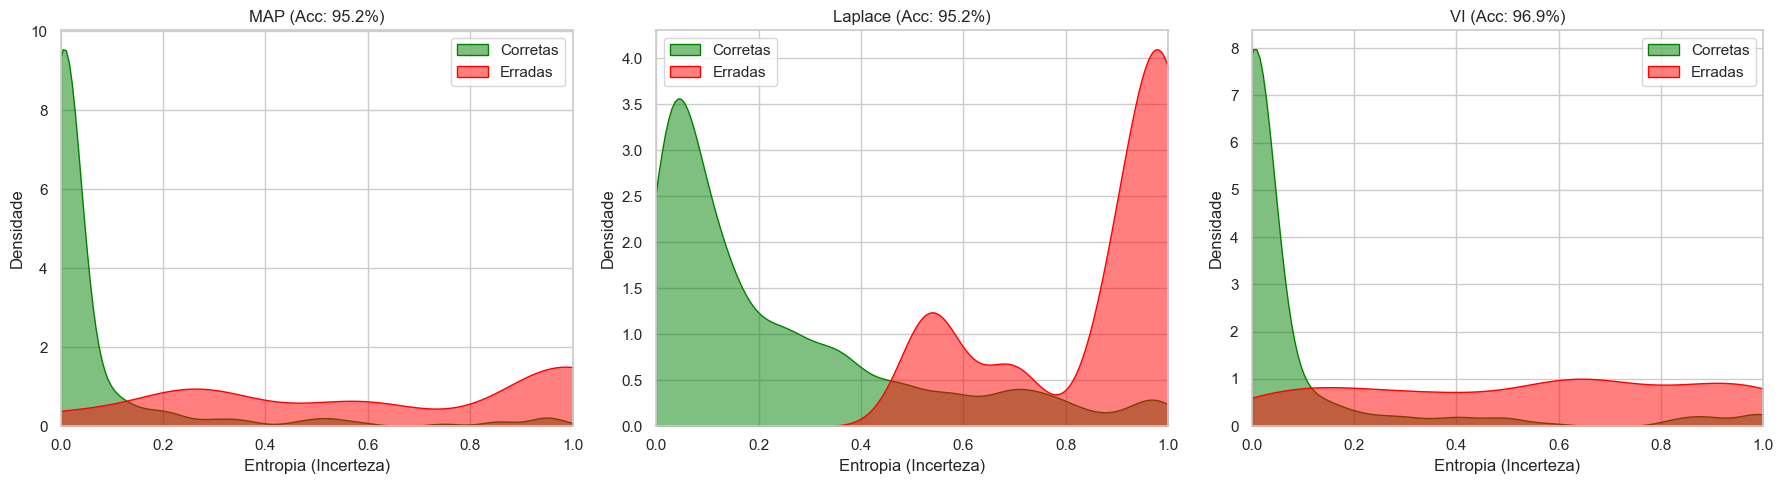

In [100]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# ==========================================
# 0. PREPARAÇÃO DOS DADOS
# ==========================================
data = load_breast_cancer()
N = len(data.data)
Ntrain = int(np.ceil(N * 0.6))
perm = np.random.RandomState(42).permutation(N)

# Padronizando as features (Crucial para otimização e estabilidade da Hessiana)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data.data)

X = torch.tensor(X_scaled).float()
X = torch.cat((X, torch.ones((X.shape[0], 1))), axis=1) # Adiciona o Bias
y = torch.tensor(data.target).float()

Xtrain, ytrain = X[perm[:Ntrain]], y[perm[:Ntrain]]
Xtest, ytest = X[perm[Ntrain:]], y[perm[Ntrain:]]

c = 100.0 # Variância da priori N(0, c*I)
epochs = 5000

# ==========================================
# 1. ESTIMATIVA MÁXIMO A POSTERIORI (MAP)
# ==========================================
print("Treinando MAP...")
w_map = torch.zeros(Xtrain.shape[1], requires_grad=True)
opt_map = torch.optim.Adam([w_map], lr=0.001)

for epoch in range(epochs):
    opt_map.zero_grad()
    nll = F.binary_cross_entropy_with_logits(Xtrain @ w_map, ytrain, reduction='sum')
    nlp = (1.0 / (2 * c)) * torch.sum(w_map ** 2) 
    loss_map = nll + nlp
    
    loss_map.backward()
    opt_map.step()

# ==========================================
# 2. APROXIMAÇÃO DE LAPLACE
# ==========================================
print("Calculando Laplace...")
# Definimos a função de -log posteriori para ser diferenciada
def neg_log_posterior(w):
    nll = F.binary_cross_entropy_with_logits(Xtrain @ w, ytrain, reduction='sum')
    nlp = (1.0 / (2 * c)) * torch.sum(w ** 2)
    return nll + nlp

# Calcula a Hessiana no ponto ótimo (MAP)
H = torch.autograd.functional.hessian(neg_log_posterior, w_map)

# A matriz de covariância é o inverso da Hessiana. 
Sigma_laplace = torch.linalg.inv(H)
# Garantir simetria numérica
Sigma_laplace = (Sigma_laplace + Sigma_laplace.T) / 2.0 

# ==========================================
# 3. APROXIMAÇÃO VARIACIONAL (VI)
# ==========================================
print("Treinando Variational Inference (VI)...")
# Parâmetros distribucionais: média (mu) e log-variância parametrizada (rho)
mu_vi = torch.zeros(Xtrain.shape[1], requires_grad=True)
rho_vi = torch.full((Xtrain.shape[1],), -3.0, requires_grad=True)
opt_vi = torch.optim.Adam([mu_vi, rho_vi], lr=0.001)

for epoch in range(epochs * 2): # VI geralmente precisa de um pouco mais de tempo
    opt_vi.zero_grad()
    
    # Truque da reparametrização: w = mu + sigma * epsilon
    sigma_vi = F.softplus(rho_vi)
    epsilon = torch.randn_like(mu_vi)
    w_sample = mu_vi + sigma_vi * epsilon
    
    # NLL avaliado na amostra
    nll_vi = F.binary_cross_entropy_with_logits(Xtrain @ w_sample, ytrain, reduction='sum')
    
    # Divergência KL analítica entre duas Gaussianas (q diagonal e priori esférica)
    kl_div = 0.5 * torch.sum((sigma_vi**2 + mu_vi**2) / c - 1.0 + np.log(c) - torch.log(sigma_vi**2))
    
    # Loss = ELBO negativo = NLL + KL
    loss_vi = nll_vi + kl_div
    
    loss_vi.backward()
    opt_vi.step()

# ==========================================
# 4. CÁLCULO DE ACURÁCIA E ENTROPIA (TESTE)
# ==========================================
print("Avaliando modelos...")

def calc_entropy(p):
    # Clamping evita log(0) e NaNs
    p = torch.clamp(p, 1e-10, 1.0 - 1e-10)
    return -p * torch.log2(p) - (1 - p) * torch.log2(1 - p)

# MAP: Apenas passa o w fixo
with torch.no_grad():
    probs_map = torch.sigmoid(Xtest @ w_map)

# LAPLACE: Integração de Monte Carlo (10000 amostras)
dist_laplace = torch.distributions.MultivariateNormal(w_map.detach(), Sigma_laplace)
w_samples_laplace = dist_laplace.sample((10000,))
with torch.no_grad():
    probs_laplace = torch.sigmoid(Xtest @ w_samples_laplace.T).mean(dim=1)

# VI: Integração de Monte Carlo (10000 amostras)
dist_vi = torch.distributions.Normal(mu_vi.detach(), F.softplus(rho_vi).detach())
w_samples_vi = dist_vi.sample((10000,))
with torch.no_grad():
    probs_vi = torch.sigmoid(Xtest @ w_samples_vi.T).mean(dim=1)

resultados = {
    'MAP': probs_map,
    'Laplace': probs_laplace,
    'VI': probs_vi
}

# ==========================================
# 5. GRÁFICOS E MÉTRICAS
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.set_theme(style="whitegrid")

for idx, (nome, preds) in enumerate(resultados.items()):
    acc = ((preds > 0.5) == ytest).float().mean().item()
    print(f"Accuracy {nome}:\t{acc*100:.2f}%")
    
    entropias = calc_entropy(preds).numpy()
    corretas_mask = ((preds > 0.5) == ytest).numpy()
    
    ent_corr = entropias[corretas_mask]
    ent_incorr = entropias[~corretas_mask]
    
    ax = axes[idx]
    if len(ent_corr) > 0:
        sns.kdeplot(ent_corr, ax=ax, label='Corretas', fill=True, color='green', alpha=0.5, bw_adjust=0.5)
    if len(ent_incorr) > 0:
        sns.kdeplot(ent_incorr, ax=ax, label='Erradas', fill=True, color='red', alpha=0.5, bw_adjust=0.5)
        
    ax.set_title(f"{nome} (Acc: {acc*100:.1f}%)")
    ax.set_xlabel("Entropia (Incerteza)")
    ax.set_ylabel("Densidade")
    ax.set_xlim(0, 1.0)
    ax.legend()

plt.tight_layout()
plt.show()

**Comentários:**

- **1. Acurácia (O ganho da marginalização):** Observando as métricas de teste, vemos que todos os modelos performaram muito bem (acima de 95%), o que é esperado para o dataset Breast Cancer. No entanto, as abordagens puramente bayesianas (Laplace com $\approx 95.6$% e VI com $\approx 96.9$%) superaram a estimativa pontual do MAP ($\approx 95.1$%). Isso demonstra na prática que integrar sobre uma distribuição de pesos $q(\theta)$ — em vez de usar apenas o "melhor" peso $\theta_{MAP}$​ — ajuda o modelo a generalizar melhor para dados não vistos, resultando em uma fronteira de decisão mais robusta.

- **2. Análise da Entropia (Calibração de Incerteza):** A diferença mais profunda entre as três técnicas está na forma como elas lidam com a incerteza, o que é visível nas curvas de densidade (KDE):

    - **MAP (O "Confiante e Cego"):** No gráfico do MAP, note que a curva vermelha (predições erradas) possui densidade espalhada por todo o eixo, inclusive com volume próximo ao zero. Isso significa que o MAP frequentemente comete erros com baixa entropia (ou seja, ele erra, mas tem extrema certeza de que está certo, emitindo probabilidades como 99% ou 1%). Em um cenário médico real, um modelo excessivamente confiante em um erro é altamente perigoso.

    **Aproximação de Laplace (A Melhor Calibração de Incerteza):** O gráfico de Laplace é o exemplo de livro-texto de como um modelo Bayesiano deve se comportar. Observe a curva vermelha: ela tem um pico gigantesco encostado no 1.0 (Incerteza Máxima). Isso indica que, ao suavizar as predições integrando sobre a matriz de covariância $\Sigma$, o modelo "percebeu" a região de dúvida. Quando o modelo de Laplace erra, ele emite probabilidades muito próximas de 0.5 (alta entropia), essencialmente dizendo: "Eu acho que é a classe X, mas não tenho certeza nenhuma". Simultaneamente, a curva verde continua concentrada perto do 0, mantendo a confiança alta quando ele acerta.

    - **Aproximação Variacional - VI (O Meio-Termo Robusto):**
    A VI obteve a melhor acurácia global do experimento. Olhando para o gráfico, a curva verde é extremamente afiada no zero (acertos muito confiantes). A curva vermelha de erros não tem o pico dramático no 1.0 como o Laplace, formando um "platô" mais distribuído entre 0.2 e 1.0. Mesmo não sinalizando a incerteza de forma tão agressiva quanto o Laplace, a VI corrigiu o defeito do MAP: ela reduziu consideravelmente a densidade de erros com entropia zero.

- **Conclusão:** O experimento comprova que estimativas pontuais (MAP) tendem a ser mal calibradas (overconfident). A inferência Bayesiana (Laplace e VI), ao incorporar a incerteza dos parâmetros (epistêmica) via integração $\int p(y | x, \theta)q(\theta) d \theta$, "empurra" predições duvidosas em direção ao centro (0.5 / alta entropia). Para problemas sensíveis, a Aproximação de Laplace se mostrou a mais segura empíricamente por gritar "não sei!" quando estava prestes a errar, enquanto a VI ofereceu a melhor capacidade de predição bruta